## 5.4 氣泡圖（Bubble Chart）

### 1. 定義  
氣泡圖是擴展自散佈圖的視覺化圖表，透過氣泡的大小來表示第三個變數的數值，常用於表達三維數據的關聯性。


### 2. 範例圖表與說明  

<div align="center">  
  <img src="https://raw.githubusercontent.com/jacklin92/ch5/main/Bubble-1.png" width="400">
</div>

**觀察與解釋**：  
此圖呈現病患的年齡與 BMI 分布，並以氣泡大小表示住院天數。  

- 年齡在 60 歲以上者多有較大的氣泡，表示住院天數較長  
- BMI 與住院天數並無明顯相關性  
- 不同性別使用不同顏色區分，有助於了解分布差異



### 3. 適用情況  
- 呈現三個變數之間的關係（X, Y, Size）  
- 比較同類型個體在額外變數上的差異  
- 顯示聚集、極值、範圍概況


### 4. 優缺點  
- **優點**：  
  - 一圖可同時表達三維數據  
  - 視覺吸引力高，能強調差異  
- **缺點**：  
  - 難以精確比較氣泡大小  
  - 點數過多會造成視覺混亂


### 5. 實際案例與圖表  

- **醫療領域**：年齡 × BMI × 住院天數  
- **電子商務**：商品價格 × 瀏覽次數 × 購買率  
- **製造領域**：設備使用率 × 維修次數 × 生產量


### 6. 實作範例：醫學領域 - 年齡、BMI 與住院天數關聯分析

#### 📁 資料說明  

| Age | BMI  | Days_Hospitalized | Gender |
|-----|------|--------------------|--------|
| 56  | 23.4 | 3                  | Male   |
| 71  | 27.1 | 7                  | Female |
| ... | ...  | ...                | ...    |

📥 [下載資料集：`patient_bubble_data.csv`](sandbox:/mnt/data/patient_bubble_data.csv)


In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
path = '/content/drive/MyDrive/Colab Notebooks/CH5_dataset/datasets'
img_path = '/content/drive/MyDrive/Colab Notebooks/CH5_dataset/images'

Mounted at /content/drive


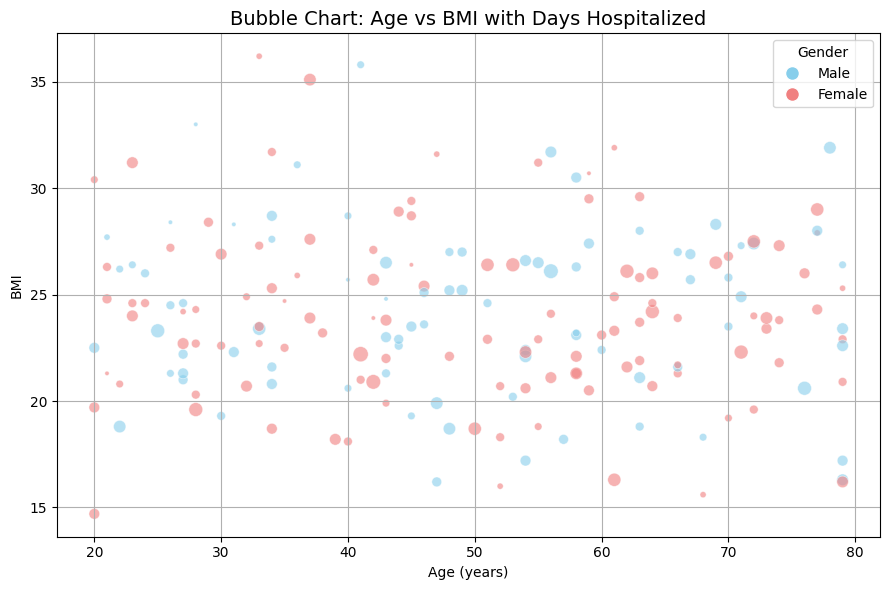

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 載入資料
from pathlib import Path

data_file = "patient_bubble_data.csv"
df = pd.read_csv(path+"/"+data_file)

# 建立顏色對應（依性別）
color_map = {"Male": "skyblue", "Female": "lightcoral"}
colors = df["Gender"].map(color_map)

# 繪製氣泡圖
plt.figure(figsize=(9, 6))
plt.scatter(
    df["Age"],
    df["BMI"],
    s=df["Days_Hospitalized"] * 10,   # 大小依住院天數放大
    c=colors,
    alpha=0.6,
    edgecolors="w",
    linewidth=0.5
)

plt.title("Bubble Chart: Age vs BMI with Days Hospitalized", fontsize=14)
plt.xlabel("Age (years)")
plt.ylabel("BMI")
plt.grid(True)

# 加入圖例
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Male',
           markerfacecolor='skyblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Female',
           markerfacecolor='lightcoral', markersize=10)
]
plt.legend(handles=legend_elements, title="Gender")

plt.tight_layout()
plt.show()

### Try it!：6. 實作範例：醫學領域 - 年齡、BMI 與住院天數關聯分析
把住院天數分級後上色，觀察長住病患集中在哪些年齡與 BMI 區間。

**程式要求**
1. 讀取 `datasets/patient_bubble_data.csv`，用 `pd.cut` 建立 `Stay_Level` 欄位：3 天以下為 `Short`、3 到 7 天為 `Medium`、超過 7 天為 `Long`，並印出各級人數。
2. 繪製氣泡圖並依 `Stay_Level` 分色（綠、橘、紅）。
3. 加上圖例、標題與軸標籤。

#### 📌 參數與樣式設定補充參考表

| 參數        | 說明                     | 範例值                           |
|-------------|--------------------------|----------------------------------|
| `s`         | 氣泡大小                 | `變數 * 10`、常數列表            |
| `c`         | 顏色                     | 類別對應、色碼、顏色名稱        |
| `alpha`     | 透明度                   | `0.4`, `0.6`, `1.0`              |
| `edgecolors`| 邊框顏色                 | `"black"`, `"w"`（白）           |
| `linewidth` | 邊框線條粗細             | `0.5`, `1.0`                     |


#### 📝 練習任務建議

1. **調整氣泡大小比例 (`s=...`)**：放大或縮小觀察視覺效果  
2. **嘗試不同顏色配置**：使用 `matplotlib.cm` 或其他色碼  
3. **加入 `hue` 或分類圖例自動產生**（若用 seaborn）  
4. **試著加入第四變數作為 `alpha` 或圖形樣式**  
5. **用 seaborn 的 `sns.scatterplot()` 繪製對比效果**
